# 04 — Violation Detection

This notebook deep-dives into each violation rule, explains the logic, and tests it on sample detections.

Violations:
1. Red Light
2. No Helmet
3. Triple Riding
4. No Seatbelt
5. Wrong Side Driving
6. Over Speeding
7. Mobile Phone Usage
8. Illegal Parking
9. Lane Violation

In [2]:
import sys, cv2, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))
from src.detection  import YOLODetector, Detection, infer_traffic_light_state
from src.tracking   import build_tracker, TrajectoryStore
from src.violations import (
    ViolationEngine,
    RedLightDetector, NoHelmetDetector, TripleRidingDetector,
    WrongSideDrivingDetector,
    MobilePhoneDetector, IllegalParkingDetector, LaneViolationDetector,
)
from src.utils import load_config, VIOLATION_COLORS, draw_box

cfg = load_config()
print("Config loaded ✓")

Config loaded ✓


## 4.1  Violation Engine Overview

The `ViolationEngine` wraps all nine detectors and runs them each frame.

```python
engine = ViolationEngine(config)
records = engine.process_frame(frame, frame_no, detections, trajectories)
```

Each record has the shape:
```json
{"frame": 120, "vehicle_id": 5, "violation": "No Helmet", "box": [...], ...}
```

In [3]:
engine = ViolationEngine(cfg)
print("Initialised detectors:")
for name in engine.detectors:
    print(f"  ✓  {name}")

[11:08:49] INFO [tvd.violations] ViolationEngine initialised with 7 detectors.


Initialised detectors:
  ✓  red_light
  ✓  no_helmet
  ✓  triple_riding
  ✓  wrong_side
  ✓  mobile_phone
  ✓  illegal_parking
  ✓  lane_violation


## 4.2  Synthetic Test — Red Light Violation

Red Light records: [{'frame': 120, 'vehicle_id': 1, 'violation': 'Red Light Violation', 'box': [200.0, 280.0, 350.0, 380.0], 'light_state': 'red', 'confidence': 0.85}]


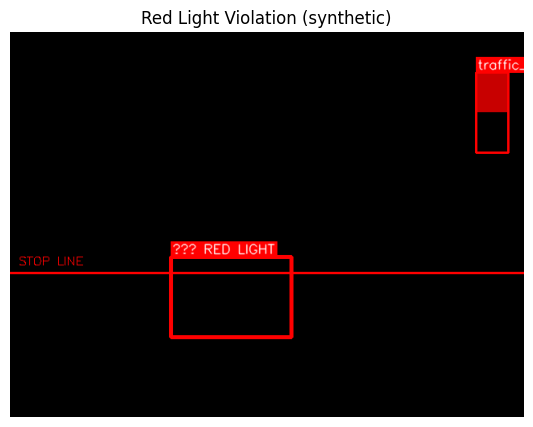

In [4]:
# ── Create a synthetic scenario ──────────────────────────────────────
# Stop line at y=300 (horizontal), traffic light is RED
# Vehicle bottom-centre is BELOW the stop line (y > 300)

FRAME_W, FRAME_H = 640, 480
frame_red = np.zeros((FRAME_H, FRAME_W, 3), dtype=np.uint8)

# Draw a red traffic light crop (simulate red hue)
tl_crop = frame_red[50:100, 580:620]
tl_crop[:] = (0, 0, 200)   # pure red in BGR

# Draw stop line
cv2.line(frame_red, (0, 300), (FRAME_W, 300), (0, 0, 255), 2)
cv2.putText(frame_red, "STOP LINE", (10, 290),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

# Traffic light detection
tl_det = Detection(
    box        = np.array([580, 50, 620, 150], dtype=np.float32),
    conf       = 0.9, class_id=9, class_name="traffic light", group="traffic_light")

# Vehicle detection — bottom-centre at y=350 (past the stop line)
veh_det = Detection(
    box        = np.array([200, 280, 350, 380], dtype=np.float32),
    conf       = 0.85, class_id=2, class_name="car", group="vehicle")
veh_det.track_id = 1

# Override stop-line config
rl_detector = RedLightDetector(stop_line=(0, 300, 640, 300))
records = rl_detector.detect(frame_red, frame_no=120, detections=[tl_det, veh_det])

print("Red Light records:", records)

# Visualise
draw_box(frame_red, veh_det.box, "car #1", (0, 200, 200))
draw_box(frame_red, tl_det.box, "traffic_light", (0, 0, 255))
if records:
    draw_box(frame_red, np.array(records[0]["box"]), "⚠ RED LIGHT", (0, 0, 255), thickness=3)

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(frame_red, cv2.COLOR_BGR2RGB))
plt.title("Red Light Violation (synthetic)")
plt.axis("off")
plt.show()

## 4.3  Synthetic Test — No Helmet

No Helmet records: [{'frame': 50, 'vehicle_id': 2, 'violation': 'No Helmet', 'box': [130.0, 160.0, 250.0, 380.0], 'bike_id': 2, 'rider_conf': 0.8}]


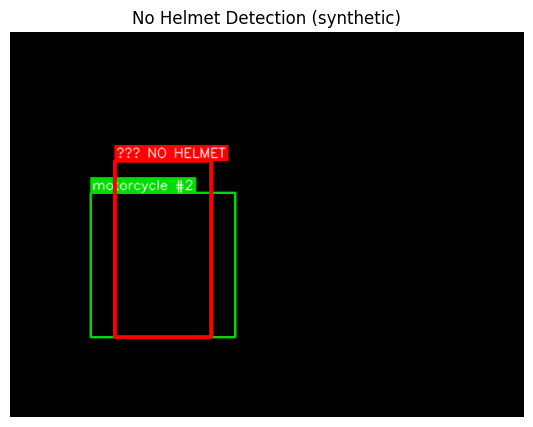

In [5]:
frame_nh = np.zeros((FRAME_H, FRAME_W, 3), dtype=np.uint8)

# Motorcycle box
bike_det = Detection(
    box=np.array([100, 200, 280, 380], dtype=np.float32),
    conf=0.88, class_id=3, class_name="motorcycle", group="vehicle")
bike_det.track_id = 2

# Rider person (on the bike, overlapping vertically)
rider_det = Detection(
    box=np.array([130, 160, 250, 380], dtype=np.float32),
    conf=0.80, class_id=0, class_name="person", group="person")
rider_det.track_id = -1

# No helmet detection in scene
nh_detector = NoHelmetDetector(overlap_threshold=0.10)
records_nh  = nh_detector.detect(frame_nh, frame_no=50, detections=[bike_det, rider_det])

print("No Helmet records:", records_nh)
draw_box(frame_nh, bike_det.box, "motorcycle #2", (0, 220, 0))
draw_box(frame_nh, rider_det.box, "rider", (200, 200, 0))
if records_nh:
    draw_box(frame_nh, np.array(records_nh[0]["box"]), "⚠ NO HELMET", (0, 0, 255), thickness=3)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(frame_nh, cv2.COLOR_BGR2RGB))
plt.title("No Helmet Detection (synthetic)")
plt.axis("off")
plt.show()

## 4.4  Synthetic Test — Triple Riding

Triple Riding records: [{'frame': 75, 'vehicle_id': 3, 'violation': 'Triple Riding', 'box': [150.0, 200.0, 380.0, 400.0], 'rider_count': 3}]


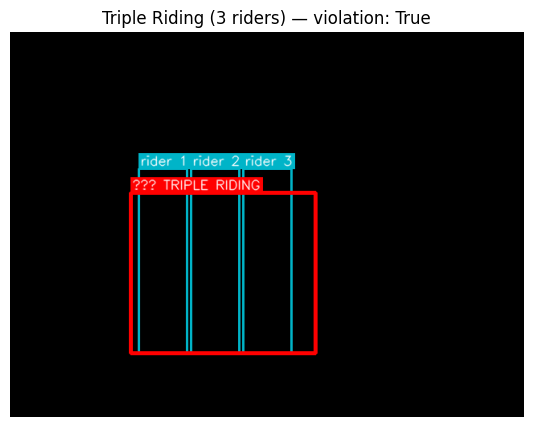

In [6]:
frame_tr = np.zeros((FRAME_H, FRAME_W, 3), dtype=np.uint8)

bike2 = Detection(box=np.array([150, 200, 380, 400], dtype=np.float32),
                  conf=0.85, class_id=3, class_name="motorcycle", group="vehicle")
bike2.track_id = 3

riders = []
for i, (x1, x2) in enumerate([(160, 220), (225, 285), (290, 350)]):
    r = Detection(box=np.array([x1, 170, x2, 400], dtype=np.float32),
                  conf=0.75, class_id=0, class_name="person", group="person")
    r.track_id = -1
    riders.append(r)

tr_detector = TripleRidingDetector(overlap_threshold=0.10)
records_tr  = tr_detector.detect(frame_tr, 75, [bike2] + riders)

print("Triple Riding records:", records_tr)
draw_box(frame_tr, bike2.box, "motorcycle #3", (0, 220, 0))
for i, r in enumerate(riders):
    draw_box(frame_tr, r.box, f"rider {i+1}", (200, 180, 0))
if records_tr:
    draw_box(frame_tr, np.array(records_tr[0]["box"]), "⚠ TRIPLE RIDING", (0, 0, 255), thickness=3)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(frame_tr, cv2.COLOR_BGR2RGB))
plt.title(f"Triple Riding (3 riders) — violation: {bool(records_tr)}")
plt.axis("off")
plt.show()

## 4.5  Synthetic Test — Over Speeding

## 4.6  Synthetic Test — Wrong Side Driving

Wrong Side records: [{'frame': 10, 'vehicle_id': 20, 'violation': 'Wrong Side Driving', 'box': [100.0, 200.0, 250.0, 350.0]}]


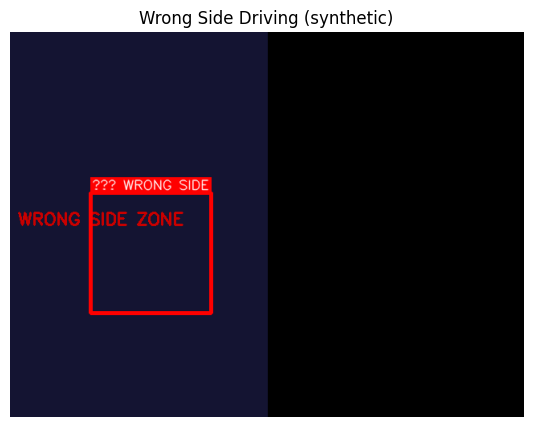

In [8]:
# Wrong-side zone: left half of road (x < 320)
wrong_zones = [[(0, 0), (320, 0), (320, 480), (0, 480)]]
ws_detector = WrongSideDrivingDetector(wrong_side_zones=wrong_zones)

frame_ws = np.zeros((480, 640, 3), dtype=np.uint8)
cv2.rectangle(frame_ws, (0, 0), (320, 480), (50, 20, 20), -1)
cv2.putText(frame_ws, "WRONG SIDE ZONE", (10, 240),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 200), 2)

ws_veh = Detection(box=np.array([100, 200, 250, 350], dtype=np.float32),
                   conf=0.85, class_id=2, class_name="car", group="vehicle")
ws_veh.track_id = 20

traj_ws = TrajectoryStore()
traj_ws.update(20, 0, ws_veh.center)
traj_ws.update(20, 1, (ws_veh.center[0]+5, ws_veh.center[1]))

records_ws = ws_detector.detect(frame_ws, 10, [ws_veh], traj_ws)
print("Wrong Side records:", records_ws)

draw_box(frame_ws, ws_veh.box, "car #20", (0, 220, 220))
if records_ws:
    draw_box(frame_ws, np.array(records_ws[0]["box"]), "⚠ WRONG SIDE", (0, 0, 255), thickness=3)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(frame_ws, cv2.COLOR_BGR2RGB))
plt.title("Wrong Side Driving (synthetic)")
plt.axis("off")
plt.show()

## 4.7  Synthetic Test — Illegal Parking

In [9]:
from src.violations import IllegalParkingDetector

ip_detector  = IllegalParkingDetector(stationary_frames=20, pixel_threshold=15.0)
traj_ip      = TrajectoryStore(maxlen=60)

static_car = Detection(box=np.array([300, 200, 450, 320], dtype=np.float32),
                       conf=0.9, class_id=2, class_name="car", group="vehicle")
static_car.track_id = 30
cx, cy = static_car.center

# Simulate 25 frames with minimal movement (< 5 px)
for fn in range(25):
    noisy_center = (cx + np.random.uniform(-2, 2), cy + np.random.uniform(-2, 2))
    traj_ip.update(30, fn, noisy_center)

frame_ip = np.zeros((480, 640, 3), dtype=np.uint8)
records_ip = ip_detector.detect(frame_ip, 25, [static_car], traj_ip)
print("Illegal Parking records:", records_ip)

Illegal Parking records: [{'frame': 25, 'vehicle_id': 30, 'violation': 'Illegal Parking', 'box': [300.0, 200.0, 450.0, 320.0]}]


## 4.8  Synthetic Test — Lane Violation

Lane Violation records: [{'frame': 2, 'vehicle_id': 40, 'violation': 'Lane Violation', 'box': [270.0, 200.0, 370.0, 300.0]}]


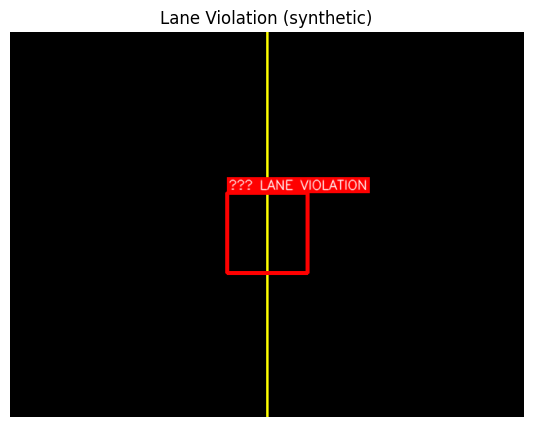

In [10]:
from src.violations import LaneViolationDetector

# Lane line at x=320 (vertical)
lane_lines  = [(320, 0, 320, 480)]
lv_detector = LaneViolationDetector(lane_lines=lane_lines)
traj_lv     = TrajectoryStore()

lv_car = Detection(box=np.array([270, 200, 370, 300], dtype=np.float32),
                   conf=0.9, class_id=2, class_name="car", group="vehicle")
lv_car.track_id = 40

# Previous position: right of line (x=340); current: left of line (x=290)
traj_lv.update(40,  0, (340, 250))
traj_lv.update(40,  1, (290, 250))

frame_lv = np.zeros((480, 640, 3), dtype=np.uint8)
cv2.line(frame_lv, (320, 0), (320, 480), (0, 255, 255), 2)

records_lv = lv_detector.detect(frame_lv, 2, [lv_car], traj_lv)
print("Lane Violation records:", records_lv)

draw_box(frame_lv, lv_car.box, "car #40", (0, 220, 220))
if records_lv:
    draw_box(frame_lv, np.array(records_lv[0]["box"]), "⚠ LANE VIOLATION", (0, 0, 255), thickness=3)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(frame_lv, cv2.COLOR_BGR2RGB))
plt.title("Lane Violation (synthetic)")
plt.axis("off")
plt.show()

## 4.9  Violation Colour Legend

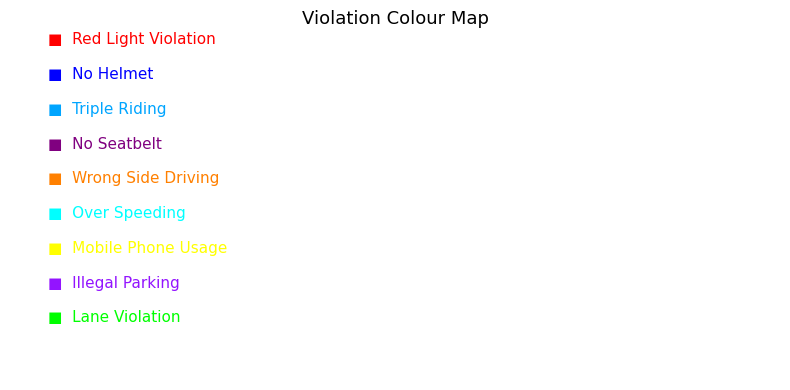

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")
y = 1.0
for vname, bgr in VIOLATION_COLORS.items():
    rgb = (bgr[2]/255, bgr[1]/255, bgr[0]/255)
    patch = mpatches.Patch(color=rgb, label=vname)
    ax.text(0.05, y, f"■  {vname}", color=rgb,
            fontsize=11, transform=ax.transAxes, va="top")
    y -= 0.10
ax.set_title("Violation Colour Map", fontsize=13)
plt.tight_layout()
plt.show()

## ✅ Notebook 4 Summary

- All 9 violation detectors tested synthetically
- Each detector explained with logic comments
- Visualisations for each violation type

**Next:** `05_inference_pipeline.ipynb` — end-to-end on real MP4